# Description: Evaluate NORDIC ability at removing Thermal Noise

Prior to using this notebook, you need to run the ```bash/S03_ThermalNoiseEstimation...``` script to estimate thermal noise in all scans and TEs from both datasets.

For each scan, this script will write two files:

* ```{sbj}_{ses}_task-rest_echo-{e}_bold.NORDIC_off.ThermalNoise.txt```: holds thermal noise estimates before applying NORDIC.
* ```{sbj}_{ses}_task-rest_echo-{e}_bold.NORDIC_on.ThermalNoise.txt```: holds thermal noise estimates after applying NORDIC.

Expectations:

* Thermal noise should be TE independent, yet becuase the suboptimal way in which we are measuring thermal noise, a slight difference migth occur.
* Thermal noise should be significantly smaller after NORDIC for all echoes.

In [1]:
import pandas as pd
import os.path as osp
import hvplot.pandas
import seaborn as sns
import numpy as np
import panel as pn
from tqdm import tqdm
from utils.basics import PRCS_DATA_DIR, PRJ_DIR
from statannotations.Annotator import Annotator
import matplotlib.pyplot as plt
import xarray as xr
import hvplot.xarray
import holoviews as hv

In [2]:
import os
port_tunnel = int(os.environ['PORT2'])
print('++ INFO: Second Port available: %d' % port_tunnel)

++ INFO: Second Port available: 45109


***

# Thermal Noise Removal in Discovery Dataset

In [3]:
sbj_list = ['MGSBJ01',  'MGSBJ02',  'MGSBJ03',  'MGSBJ04',  'MGSBJ05',  'MGSBJ06',  'MGSBJ07']
ses_list = ['constant_gated', 'cardiac_gated']
dataset_info_df = pd.DataFrame(index=pd.MultiIndex.from_product([sbj_list,ses_list],names=['Subject','Session']))

In [4]:
#df = pd.DataFrame(columns=['Subject','Session','NORDIC','Echo','Thermal Noise'])
df_list = []
for sbj,ses in tqdm(dataset_info_df.index, desc='Scan'):
    for e in range(1,4):
        aux_path = osp.join(PRCS_DATA_DIR,sbj,'D02_NORDIC',f'{sbj}_{ses}_task-rest_echo-{e}_bold.NORDIC_off.ThermalNoise.txt')
        aux      = np.loadtxt(aux_path)
        df_list.append( {'Subject':sbj,'Session':ses,'NORDIC':'off','Echo':e,'Thermal Noise':np.mean(aux[10::])})
        aux_path = osp.join(PRCS_DATA_DIR,sbj,'D02_NORDIC',f'{sbj}_{ses}_task-rest_echo-{e}_bold.NORDIC_on.ThermalNoise.txt')
        aux      = np.loadtxt(aux_path)
        df_list.append( {'Subject':sbj,'Session':ses,'NORDIC':'on','Echo':e,'Thermal Noise':np.mean(aux[10::])})
df = pd.DataFrame(df_list)

Scan: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 198.82it/s]


In [5]:
df_ConstG = df.set_index('Session').loc['constant_gated'].copy().reset_index(drop=True)
df_CardG  = df.set_index('Session').loc['cardiac_gated'].copy().reset_index(drop=True)

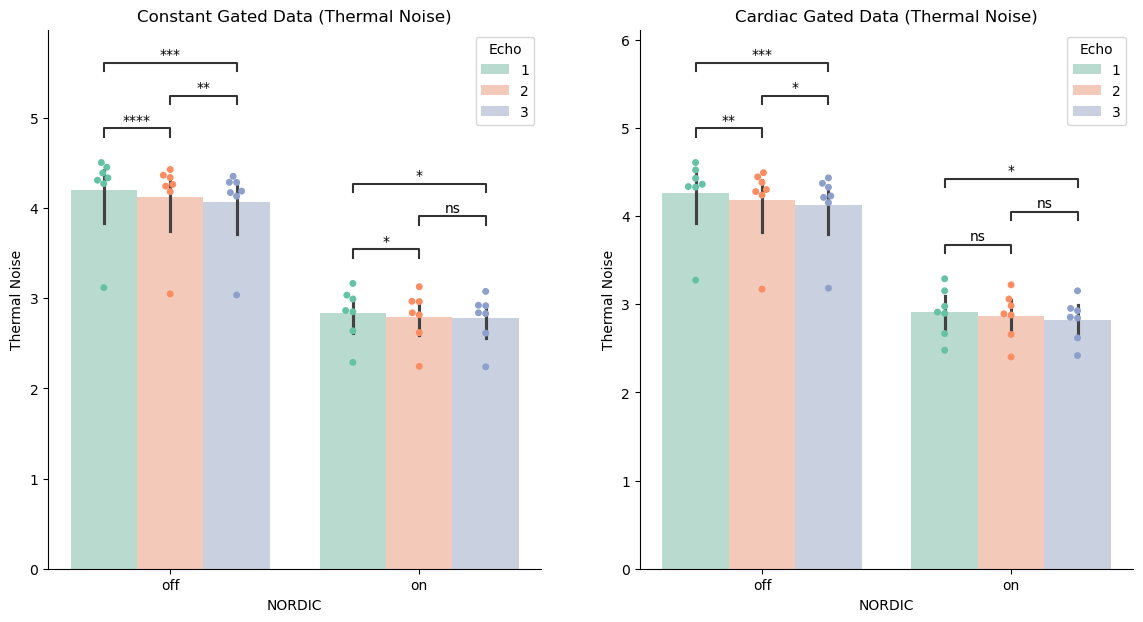

In [6]:
fig, axs = plt.subplots(1,2,figsize=(14,7))
# Results for Constant Gated
sns.barplot(  data=df_ConstG,x='NORDIC',hue='Echo',y='Thermal Noise', palette='Set2', errorbar='ci', ax=axs[0], alpha=0.5).set_title('Constant Gated Data (Thermal Noise)')
sns.swarmplot(data=df_ConstG,x='NORDIC',hue='Echo',y='Thermal Noise', palette='Set2',ax=axs[0], dodge=True, legend=False)
pairs=[(('off',1),('off',2)),(('off',2),('off',3)),(('off',1),('off',3)),(('on',1),('on',2)),(('on',2),('on',3)),(('on',1),('on',3))]
annotation = Annotator(axs[0], pairs, data=df_ConstG, x='NORDIC', y='Thermal Noise',hue='Echo')
annotation.configure(test='t-test_paired', loc='inside', verbose=0, comparisons_correction="Bonferroni");
annotation.apply_test(alternative='two-sided');
annotation.annotate();
# Results for Cardiac Gated
sns.barplot(  data=df_CardG,x='NORDIC',hue='Echo',y='Thermal Noise', palette='Set2', errorbar='ci', ax=axs[1], alpha=0.5).set_title('Cardiac Gated Data (Thermal Noise)')
sns.swarmplot(data=df_CardG,x='NORDIC',hue='Echo',y='Thermal Noise', palette='Set2',ax=axs[1], dodge=True, legend=False)
sns.despine()
pairs=[(('off',1),('off',2)),(('off',2),('off',3)),(('off',1),('off',3)),(('on',1),('on',2)),(('on',2),('on',3)),(('on',1),('on',3))]
annotation = Annotator(axs[1], pairs, data=df_CardG, x='NORDIC', y='Thermal Noise',hue='Echo')
annotation.configure(test='t-test_paired', loc='inside', verbose=0, comparisons_correction="Bonferroni");
annotation.apply_test(alternative='two-sided');
annotation.annotate();

Same as above, but showing statistical test across NORDIC scenarios

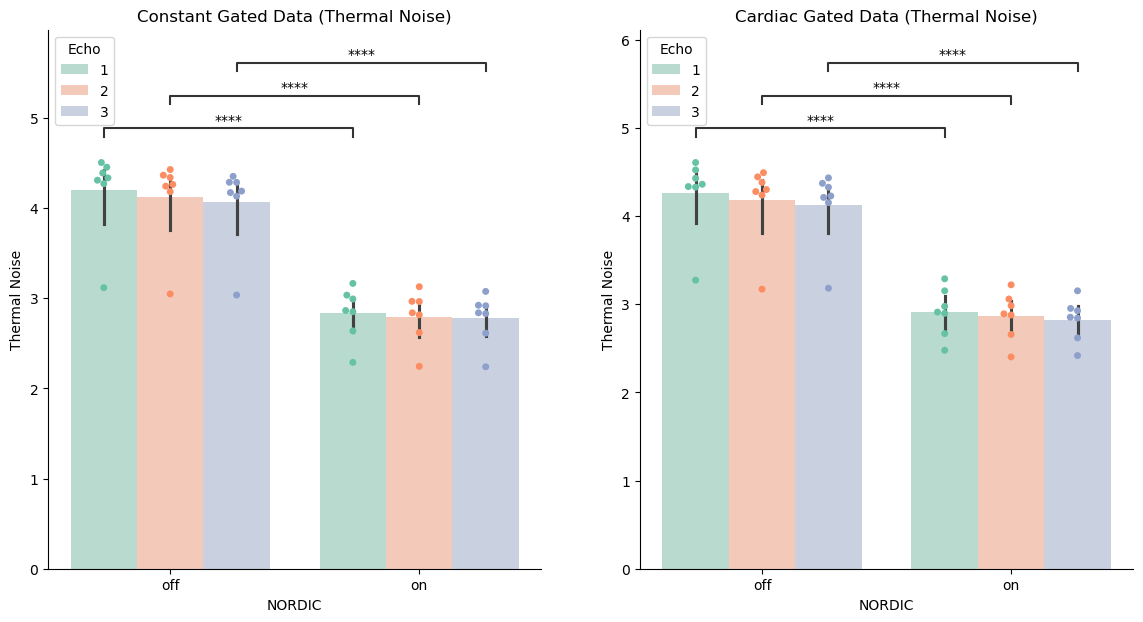

In [7]:
fig, axs = plt.subplots(1,2,figsize=(14,7))
# Results for Constant Gated
sns.barplot(  data=df_ConstG,x='NORDIC',hue='Echo',y='Thermal Noise', palette='Set2', errorbar='ci', ax=axs[0], alpha=0.5).set_title('Constant Gated Data (Thermal Noise)')
sns.swarmplot(data=df_ConstG,x='NORDIC',hue='Echo',y='Thermal Noise', palette='Set2',ax=axs[0], dodge=True, legend=False)
pairs=[(('off',1),('on',1)),(('off',2),('on',2)),(('off',3),('on',3))]
annotation = Annotator(axs[0], pairs, data=df_ConstG, x='NORDIC', y='Thermal Noise',hue='Echo')
annotation.configure(test='t-test_paired', loc='inside', verbose=0, comparisons_correction="Bonferroni");
annotation.apply_test(alternative='two-sided');
annotation.annotate();
# Results for Cardiac Gated
sns.barplot(  data=df_CardG,x='NORDIC',hue='Echo',y='Thermal Noise', palette='Set2', errorbar='ci', ax=axs[1], alpha=0.5).set_title('Cardiac Gated Data (Thermal Noise)')
sns.swarmplot(data=df_CardG,x='NORDIC',hue='Echo',y='Thermal Noise', palette='Set2',ax=axs[1], dodge=True, legend=False)
sns.despine()
pairs=[(('off',1),('on',1)),(('off',2),('on',2)),(('off',3),('on',3))]
annotation = Annotator(axs[1], pairs, data=df_CardG, x='NORDIC', y='Thermal Noise',hue='Echo')
annotation.configure(test='t-test_paired', loc='inside', verbose=0, comparisons_correction="Bonferroni");
annotation.apply_test(alternative='two-sided');
annotation.annotate();

This next section creates a small dashboard to explore how thermal noise changes over time

In [8]:
xr_th = xr.DataArray(dims=['Subject','Session','NORDIC','Echo','TR'],
                     coords={'Subject':sbj_list,'Session':ses_list,'NORDIC':['on','off'],'Echo':range(1,4),'TR':range(185)}, name='Thermal Noise')

In [9]:
for sbj,ses in tqdm(dataset_info_df.index, desc='Scan'):
    for e in range(1,4):
        for NORDIC in ['on','off']:
            aux_path = osp.join(PRCS_DATA_DIR,sbj,'D02_NORDIC',f'{sbj}_{ses}_task-rest_echo-{e}_bold.NORDIC_{NORDIC}.ThermalNoise.txt')
            xr_th.loc[sbj,ses,NORDIC,e,:]      = np.loadtxt(aux_path)[10::]

Scan: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 143.68it/s]


In [10]:
sbj_sel = pn.widgets.Select(name='Subject', options=sbj_list, width=150)
ses_sel = pn.widgets.Select(name='Session', options=ses_list, width=150)
nor_sel = pn.widgets.Select(name='NORDIC', options=['on','off'], width=150)

@pn.depends(sbj_sel,ses_sel,nor_sel)
def get_th_timeseries_plot(sbj,ses,NORDIC):
    line_plot = xr_th.sel(Subject=sbj,Session=ses,NORDIC=NORDIC).hvplot.line(by='Echo',width=1750, height=400)
    aux_means = xr_th.sel(Subject=sbj,Session=ses,NORDIC=NORDIC).mean(dim='TR').values
    e1_mean_line = hv.HLine(aux_means[0]).opts(color='lightblue', line_width=3, line_dash='dashed')
    e2_mean_line = hv.HLine(aux_means[1]).opts(color='red', line_width=3, line_dash='dashed')
    e3_mean_line = hv.HLine(aux_means[2]).opts(color='orange', line_width=3, line_dash='dashed')

    return e1_mean_line * e2_mean_line * e3_mean_line * line_plot 

In [11]:
dashboard = pn.Row(pn.Card(sbj_sel,ses_sel,nor_sel, hide_header=True), get_th_timeseries_plot).show(port=port_tunnel)

Launching server at http://localhost:45109


In [12]:
dashboard.stop()

***

# Thermal Noise Removal in Evaluation Dataset

In [13]:
dataset_info_df = pd.read_csv(osp.join(PRJ_DIR,'resources','good_scans.txt'))
dataset_info_df = dataset_info_df.set_index(['Subject','Session'])
print('++ Number of scans: %s scans' % dataset_info_df.shape[0])

++ Number of scans: 439 scans


In [14]:
df_list = []
for sbj,ses in tqdm(dataset_info_df.index, desc='Scan'):
    for e in range(1,4):
        aux_path = osp.join(PRCS_DATA_DIR,sbj,'D02_NORDIC',f'{sbj}_{ses}_task-rest_echo-{e}_bold.NORDIC_off.ThermalNoise.txt')
        aux      = np.loadtxt(aux_path)
        df_list.append( {'Subject':sbj,'Session':ses,'NORDIC':'off','Echo':e,'Thermal Noise':np.mean(aux[10::])})
        aux_path = osp.join(PRCS_DATA_DIR,sbj,'D02_NORDIC',f'{sbj}_{ses}_task-rest_echo-{e}_bold.NORDIC_on.ThermalNoise.txt')
        aux      = np.loadtxt(aux_path)
        df_list.append( {'Subject':sbj,'Session':ses,'NORDIC':'on','Echo':e,'Thermal Noise':np.mean(aux[10::])})
df = pd.DataFrame(df_list)

Scan: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 439/439 [00:14<00:00, 30.26it/s]


In [15]:
df_ses1 = df.set_index('Session').loc['ses-1'].copy().reset_index(drop=True)
df_ses2  = df.set_index('Session').loc['ses-2'].copy().reset_index(drop=True)

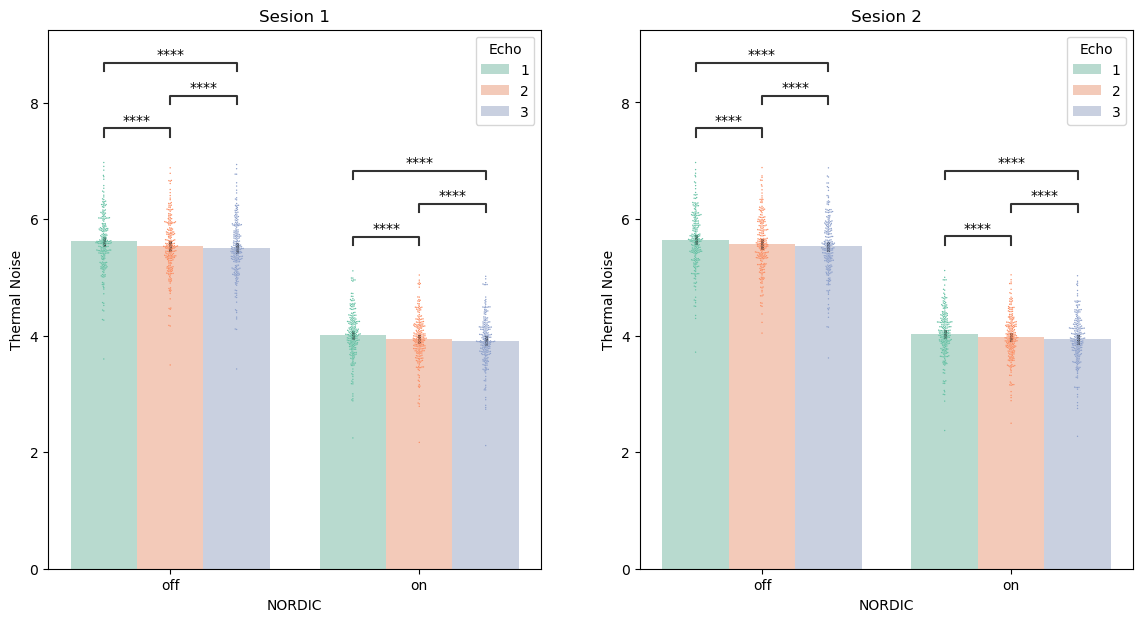

In [16]:
fig, axs = plt.subplots(1,2,figsize=(14,7))
# Results for Constant Gated
sns.barplot(  data=df_ses1,x='NORDIC',hue='Echo',y='Thermal Noise', palette='Set2', errorbar='ci', ax=axs[0], alpha=0.5).set_title('Sesion 1')
sns.swarmplot(data=df_ses1,x='NORDIC',hue='Echo',y='Thermal Noise', palette='Set2',ax=axs[0], dodge=True, legend=False, size=1)
pairs=[(('off',1),('off',2)),(('off',2),('off',3)),(('off',1),('off',3)),(('on',1),('on',2)),(('on',2),('on',3)),(('on',1),('on',3))]
annotation = Annotator(axs[0], pairs, data=df_ses1, x='NORDIC', y='Thermal Noise',hue='Echo')
annotation.configure(test='t-test_paired', loc='inside', verbose=0, comparisons_correction="Bonferroni");
annotation.apply_test(alternative='two-sided');
annotation.annotate();
# Results for Cardiac Gated
sns.barplot(  data=df_ses2,x='NORDIC',hue='Echo',y='Thermal Noise', palette='Set2', errorbar='ci', ax=axs[1], alpha=0.5).set_title('Sesion 2')
sns.swarmplot(data=df_ses2,x='NORDIC',hue='Echo',y='Thermal Noise', palette='Set2',ax=axs[1], dodge=True, legend=False, size=1)
pairs=[(('off',1),('off',2)),(('off',2),('off',3)),(('off',1),('off',3)),(('on',1),('on',2)),(('on',2),('on',3)),(('on',1),('on',3))]
annotation = Annotator(axs[1], pairs, data=df_ses2, x='NORDIC', y='Thermal Noise',hue='Echo')
annotation.configure(test='t-test_paired', loc='inside', verbose=0, comparisons_correction="Bonferroni");
annotation.apply_test(alternative='two-sided');
annotation.annotate();

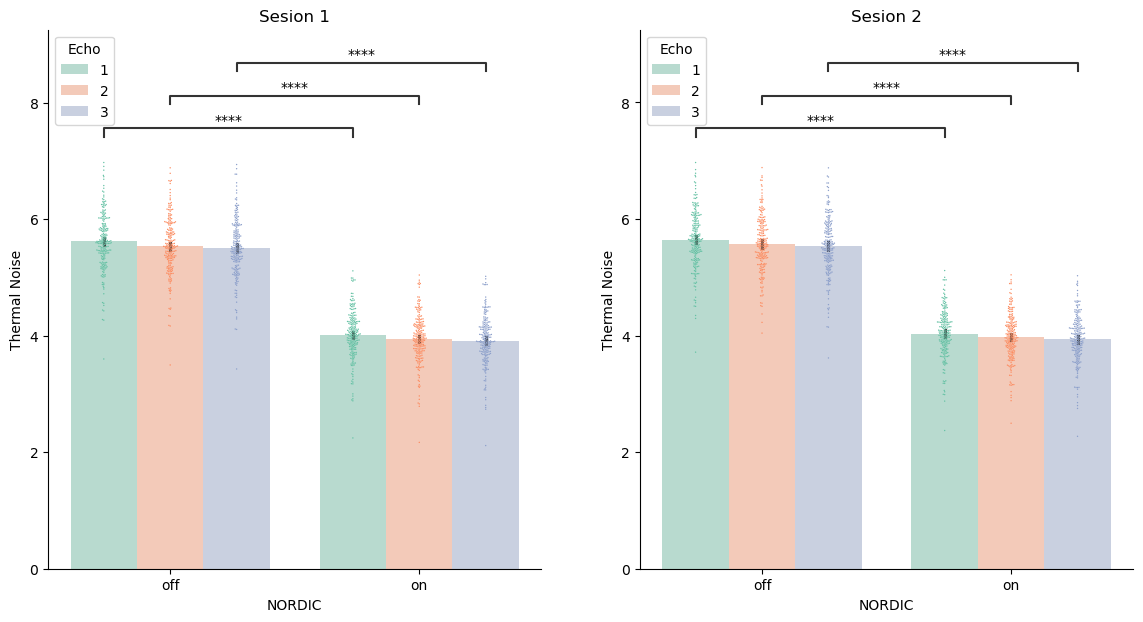

In [17]:
fig, axs = plt.subplots(1,2,figsize=(14,7))
# Results for Constant Gated
sns.barplot(  data=df_ses1,x='NORDIC',hue='Echo',y='Thermal Noise', palette='Set2', errorbar='ci', ax=axs[0], alpha=0.5).set_title('Sesion 1')
sns.swarmplot(data=df_ses1,x='NORDIC',hue='Echo',y='Thermal Noise', palette='Set2',ax=axs[0], dodge=True, legend=False, size=1)
pairs=[(('off',1),('on',1)),(('off',2),('on',2)),(('off',3),('on',3))]
annotation = Annotator(axs[0], pairs, data=df_ses1, x='NORDIC', y='Thermal Noise',hue='Echo')
annotation.configure(test='t-test_paired', loc='inside', verbose=0, comparisons_correction="Bonferroni");
annotation.apply_test(alternative='two-sided');
annotation.annotate();
# Results for Cardiac Gated
sns.barplot(  data=df_ses2,x='NORDIC',hue='Echo',y='Thermal Noise', palette='Set2', errorbar='ci', ax=axs[1], alpha=0.5).set_title('Sesion 2')
sns.swarmplot(data=df_ses2,x='NORDIC',hue='Echo',y='Thermal Noise', palette='Set2',ax=axs[1], dodge=True, legend=False, size=1)
pairs=[(('off',1),('on',1)),(('off',2),('on',2)),(('off',3),('on',3))]
sns.despine()
annotation = Annotator(axs[1], pairs, data=df_ses2, x='NORDIC', y='Thermal Noise',hue='Echo')
annotation.configure(test='t-test_paired', loc='inside', verbose=0, comparisons_correction="Bonferroni");
annotation.apply_test(alternative='two-sided');
annotation.annotate();